In [ ]:
# build a model to schedule weekly shifts for a small campus food store
# use ampl library

In [1]:
# install dependencies and select solver
%pip install -q amplpy pandas matplotlib

SOLVER = "highs"

from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 15.4 MB/s eta 0:00:00
Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


In [2]:
%%writefile shift_schedule.mod

# sets
# ordered set of avaiable workers
set WORKERS ordered;
# ordered sets of days and shifts
set DAYS ordered;
set SHIFTS ordered;
# set of day, shift time slots
set SLOTS within {DAYS, SHIFTS};
# set of 24 hour time blocks
set BLOCKS within {SLOTS, SLOTS, SLOTS};
# set of weekend shifts
set WEEKENDS within SLOTS;

# parameters
# number of workers required for each slot
param WorkersRequired{SLOTS};
# max hours per week per worker
param Hours;
# weight of the weekend component in the objective function
param gamma default 0.1;

# variables
# assign[worker, day, shift] = 1 assigns worker to a time slot
var assign{WORKERS, SLOTS} binary;
# weekend[worker] = 1 worker is assigned weekend shift
var weekend{WORKERS} binary;
# needed[worker] = 1
var needed{WORKERS} binary;

# constraints
# assign a sufficient number of workers for each time slot
s.t. required_workers {(day, shift) in SLOTS}:
    WorkersRequired[day, shift] == sum{worker in WORKERS} assign[worker, day, shift];
# workers limited to forty hours per week assuming 8 hours per shift
s.t. forty_hour_limit {worker in WORKERS}:
    8 * sum{(day, shift) in SLOTS} assign[worker, day, shift] <= Hours;
# workers are assigned no more than one time slot per 24 time block
s.t. required_rest {worker in WORKERS, (d1, s1, d2, s2, d3, s3) in BLOCKS}:
    assign[worker, d1, s1] + assign[worker, d2, s2] + assign[worker, d3, s3] <= 1;
# determine if a worker is assigned to any shift
s.t. is_needed {worker in WORKERS}:
    sum{(day, shift) in SLOTS} assign[worker, day, shift] <= card(SLOTS) * needed[worker];
# determine if a worker is assigned to a weekend shift
s.t. is_weekend {worker in WORKERS}:
    6 * weekend[worker] >= sum{(day, shift) in WEEKENDS} assign[worker, day, shift];

# choose(uncomment) one of the following objective functions

# minimize a blended objective of needed workers and needed weekend workers
#minimize minimize_workers:
    #sum{worker in WORKERS} needed[worker] + gamma * sum{worker in WORKERS} weekend[worker];

# weighted version: since we are minimizing the objective function a smaller weight will give higher
# priority to a given worker
# weight is obtained with the ord function, that returns the index of a given worker in the weights SET
minimize minimize_workers:
    sum{worker in WORKERS} ord(worker) * needed[worker] +
    gamma * sum{worker in WORKERS} ord(worker) * weekend[worker];

Writing shift_schedule.mod


In [ ]:
# MODEL
# The model objective is to minimize the overall number of workers needed to fill the shift and work requirements while also attempting to meet worker preferences regarding weekend shift assignments.

In [3]:
def shift_schedule(N=10, hours=40):
    """return a solved model assigning N workers to shifts"""

    workers = [f"W{i:02d}" for i in range(1, N + 1)]
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    shifts = ["morning", "evening", "night"]
    slots = [(d, s) for d in days for s in shifts]
    blocks = [(slots[i] + slots[i + 1] + slots[i + 2]) for i in range(len(slots) - 2)]
    weekends = [(d, s) for (d, s) in slots if d in ["Sat", "Sun"]]
    workers_required = {
        (d, s): (1 if s in ["night"] or d in ["Sun"] else 2)
        for d in days
        for s in shifts
    }

    m = AMPL()
    m.read("shift_schedule.mod")

    m.set["WORKERS"] = workers
    m.set["DAYS"] = days
    m.set["SHIFTS"] = shifts
    m.set["SLOTS"] = slots
    m.set["BLOCKS"] = blocks
    m.set["WEEKENDS"] = weekends
    m.param["WorkersRequired"] = workers_required
    m.param["Hours"] = hours

    m.solve(solver=SOLVER)
    assert m.solve_result == "solved", m.solve_result

    return m


m = shift_schedule(10, 40)

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 29.5
13454 simplex iterations
7 branching nodes


In [ ]:
# VISUAL

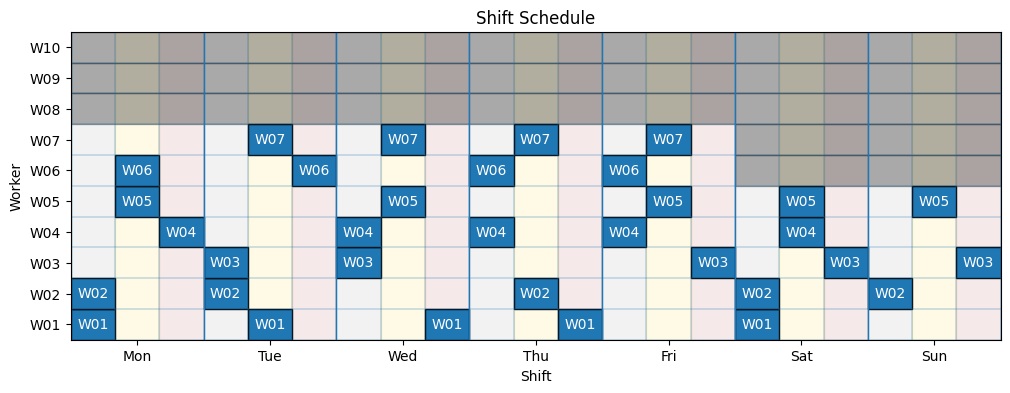

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize(m):
    workers = m.set["WORKERS"].to_list()
    slots = m.set["SLOTS"].to_list()
    days = m.set["DAYS"].to_list()

    assign = m.var["assign"].to_dict()
    needed = m.var["needed"].to_dict()
    weekend = m.var["weekend"].to_dict()

    bw = 1.0
    fig, ax = plt.subplots(1, 1, figsize=(12, 1 + 0.3 * len(workers)))
    ax.set_title("Shift Schedule")

    # x axis styling
    ax.set_xlim(0, len(slots))
    colors = ["grey", "gold", "brown"]
    for i in range(len(slots) + 1):
        ax.axvline(i, lw=0.3)
        ax.fill_between(
            [i, i + 1], [0] * 2, [len(workers)] * 2, alpha=0.1, color=colors[i % 3]
        )
    for i in range(len(days) + 1):
        ax.axvline(3 * i, lw=1)
    ax.set_xticks([3 * i + 1.5 for i in range(len(days))])
    ax.set_xticklabels(days)
    ax.set_xlabel("Shift")

    # y axis styling
    ax.set_ylim(0, len(workers))
    for j in range(len(workers) + 1):
        ax.axhline(j, lw=0.3)
    ax.set_yticks([j + 0.5 for j in range(len(workers))])
    ax.set_yticklabels(workers)
    ax.set_ylabel("Worker")

    # show shift assignments
    for i, slot in enumerate(slots):
        day, shift = slot
        for j, worker in enumerate(workers):
            if round(assign[worker, day, shift]):
                ax.add_patch(Rectangle((i, j + (1 - bw) / 2), 1, bw, edgecolor="k"))
                ax.text(
                    i + 1 / 2, j + 1 / 2, worker, ha="center", va="center", color="w"
                )

    # display needed and weekend data
    for j, worker in enumerate(workers):
        if not needed[worker]:
            ax.fill_between(
                [0, len(slots)], [j, j], [j + 1, j + 1], color="k", alpha=0.3
            )
        if needed[worker] and not weekend[worker]:
            ax.fill_between(
                [15, len(slots)], [j, j], [j + 1, j + 1], color="k", alpha=0.3
            )


visualize(m)

In [ ]:
# CREATE SCHEDULE

In [11]:
import pandas as pd

# get the schedule from AMPL and convert to pandas DataFrame with defined columns
schedule = m.var["assign"].to_list()
schedule = pd.DataFrame(
    [[s[0], s[1], s[2]] for s in schedule if s[3]], columns=["worker", "day", "shift"]
)

# create and assign a worker category type
worker_type = pd.CategoricalDtype(categories=m.set["WORKERS"].to_list(), ordered=True)
schedule["worker"] = schedule["worker"].astype(worker_type)

# create and assign a day category type
day_type = pd.CategoricalDtype(categories=m.set["DAYS"].to_list(), ordered=True)
schedule["day"] = schedule["day"].astype(day_type)

# create and assign a shift category type
shift_type = pd.CategoricalDtype(categories=m.set["SHIFTS"].to_list(), ordered=True)
schedule["shift"] = schedule["shift"].astype(shift_type)

# demonstrate sorting and display of the master schedule
schedule.sort_values(by=["day", "shift", "worker"])

,worker,day,shift
0,W01,Mon,morning
5,W02,Mon,morning
21,W05,Mon,evening
26,W06,Mon,evening
16,W04,Mon,night
9,W02,Tue,morning
13,W03,Tue,morning
3,W01,Tue,evening
31,W07,Tue,evening
28,W06,Tue,night


In [ ]:
# REPORT for Workers

In [12]:
# sort schedule by worker
schedule = schedule.sort_values(by=["worker", "day", "shift"])

# print worker schedules
for worker, worker_schedule in schedule.groupby("worker"):
    print(f"\n Work schedule for {worker}")
    if len(worker_schedule) > 0:
        for s in worker_schedule.to_string(index=False).split("\n"):
            print(s)
    else:
        print("   no assigned shifts")


 Work schedule for W01
worker day   shift
   W01 Mon morning
   W01 Tue evening
   W01 Wed   night
   W01 Thu   night
   W01 Sat morning

 Work schedule for W02
worker day   shift
   W02 Mon morning
   W02 Tue morning
   W02 Thu evening
   W02 Sat morning
   W02 Sun morning

 Work schedule for W03
worker day   shift
   W03 Tue morning
   W03 Wed morning
   W03 Fri   night
   W03 Sat   night
   W03 Sun   night

 Work schedule for W04
worker day   shift
   W04 Mon   night
   W04 Wed morning
   W04 Thu morning
   W04 Fri morning
   W04 Sat evening

 Work schedule for W05
worker day   shift
   W05 Mon evening
   W05 Wed evening
   W05 Fri evening
   W05 Sat evening
   W05 Sun evening

 Work schedule for W06
worker day   shift
   W06 Mon evening
   W06 Tue   night
   W06 Thu morning
   W06 Fri morning

 Work schedule for W07
worker day   shift
   W07 Tue evening
   W07 Wed evening
   W07 Thu evening
   W07 Fri evening

 Work schedule for W08
   no assigned shifts

 Work schedule for W09
  

/tmp/ipython-input-368998979.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for worker, worker_schedule in schedule.groupby("worker"):


In [ ]:
# REPORT for store managers

In [13]:
# sort by day, shift, worker
schedule = schedule.sort_values(by=["day", "shift", "worker"])

for day, day_schedule in schedule.groupby("day"):
    print(f"\nShift schedule for {day}")
    for shift, shift_schedule in day_schedule.groupby("shift"):
        print(f"   {shift} shift: ", end="")
        print(", ".join([worker for worker in shift_schedule["worker"].values]))


Shift schedule for Mon
   morning shift: W01, W02
   evening shift: W05, W06
   night shift: W04

Shift schedule for Tue
   morning shift: W02, W03
   evening shift: W01, W07
   night shift: W06

Shift schedule for Wed
   morning shift: W03, W04
   evening shift: W05, W07
   night shift: W01

Shift schedule for Thu
   morning shift: W04, W06
   evening shift: W02, W07
   night shift: W01

Shift schedule for Fri
   morning shift: W04, W06
   evening shift: W05, W07
   night shift: W03

Shift schedule for Sat
   morning shift: W01, W02
   evening shift: W04, W05
   night shift: W03

Shift schedule for Sun
   morning shift: W02
   evening shift: W05
   night shift: W03


/tmp/ipython-input-3457082458.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for day, day_schedule in schedule.groupby("day"):
/tmp/ipython-input-3457082458.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for shift, shift_schedule in day_schedule.groupby("shift"):


In [ ]:
# https://ampl.com/mo-book/notebooks/03/shift-scheduling.html